In [1]:
from google.colab import drive, userdata
import os
from pathlib import Path

drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
PAT      = userdata.get("GITHUB_ACCESS")
USERNAME = "shriyaasija"
REPO     = "research-copilot-gnn"

In [ ]:
if not os.path.exists(f"/content/{REPO}"):
    print("Cloning repo for the first time...")
    os.system(f"git clone https://{PAT}@github.com/{USERNAME}/{REPO}.git /content/{REPO}")
else:
    print("Repo exists — pulling latest...")
    os.system(f"cd /content/{REPO} && git pull origin main")

os.chdir(f"/content/{REPO}")

In [ ]:
!pip install -r requirements.txt
!pip install groq

In [ ]:
# Create directory structure
for d in ["data/raw", "data/processed", "data/graphs",
          "outputs/figures", "outputs/models", "src"]:
    Path(d).mkdir(parents=True, exist_ok=True)

# Check GPU
import subprocess
gpu = subprocess.getoutput("nvidia-smi --query-gpu=name --format=csv,noheader 2>/dev/null")
print(f"\n✅ Ready | GPU: {gpu if gpu else 'CPU only (switch Runtime → T4 GPU)'}")
print(f"📁 Working dir: {os.getcwd()}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle
import json
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from collections import defaultdict

# PyG imports
from torch_geometric.nn import RGCNConv, SAGEConv, GCNConv, HGTConv, HANConv
from torch_geometric.data import Data, HeteroData
from torch_geometric.transforms import ToUndirected

from sentence_transformers import SentenceTransformer

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports done | Device: {device}")

In [ ]:
with open("data/graphs/hetero_graph.pkl", "rb") as f:
    G = pickle.load(f)

with open("data/graphs/papers_list.json") as f:
    papers = json.load(f)

paper_nodes = sorted(
    [n for n, d in G.nodes(data=True) if d["node_type"] == "paper"],
    key=lambda n: int(n.split("_")[1])
)
concept_nodes = sorted(
    [n for n, d in G.nodes(data=True) if d["node_type"] == "concept"],
    key=lambda n: int(n.split("_")[1])
)
author_nodes = sorted(
    [n for n, d in G.nodes(data=True) if d["node_type"] == "author"],
    key=lambda n: int(n.split("_")[1])
)

paper_to_idx   = {n: i for i, n in enumerate(paper_nodes)}
concept_to_idx = {n: i for i, n in enumerate(concept_nodes)}
author_to_idx  = {n: i for i, n in enumerate(author_nodes)}

all_nodes    = paper_nodes + concept_nodes + author_nodes
node_to_flat = {n: i for i, n in enumerate(all_nodes)}
N_TOTAL      = len(all_nodes)
N_PAPERS     = len(paper_nodes)

print(f"Paper nodes:   {N_PAPERS}")
print(f"Concept nodes: {len(concept_nodes)}")
print(f"Author nodes:  {len(author_nodes)}")
print(f"Total nodes:   {N_TOTAL}")

In [ ]:
paper_nodes = [n for n, d in G_nx.nodes(data=True) if d["nodetype"] == "paper"]
concept_nodes = [n for n, d in G_nx.nodes(data=True) if d["nodetype"] == "concept"]
author_nodes = [n for n, d in G_nx.nodes(data=True) if d["nodetype"] == "author"]

paper_id2idx = {n: i for i, n in enumerate(paper_nodes)}
concept_id2idx = {n: i for i, n in enumerate(concept_nodes)}
author_id2idx = {n: i for i, n in enumerate(author_nodes)}

# edge lists
edges = {
    ("paper", "cites", "paper"): ([], []),
    ("paper", "mentions", "concept"): ([], []),
    ("concept", "mentioned_in", "paper"): ([], []),
    ("author", "wrote", "paper"): ([], []),
}

for u, v, d in G_nx.edges(data=True):
    et = d.get("edgetype")
    utype = G_nx.nodes[u]["nodetype"]
    vtype = G_nx.nodes[v]["nodetype"]

    if et == "cites" and utype == "paper" and vtype == "paper":
        edges[("paper", "cites", "paper")][0].append(paper_id2idx[u])
        edges[("paper", "cites", "paper")][1].append(paper_id2idx[v])
    elif et == "mentions" and utype == "paper" and vtype == "concept":
        edges[("paper", "mentions", "concept")][0].append(paper_id2idx[u])
        edges[("paper", "mentions", "concept")][1].append(concept_id2idx[v])
    elif et == "mentioned_in" and utype == "concept" and vtype == "paper":
        edges[("concept", "mentioned_in", "paper")][0].append(concept_id2idx[u])
        edges[("concept", "mentioned_in", "paper")][1].append(paper_id2idx[v])
    elif et == "wrote" and utype == "author" and vtype == "paper":
        edges[("author", "wrote", "paper")][0].append(author_id2idx[u])
        edges[("author", "wrote", "paper")][1].append(paper_id2idx[v])

num_nodes_dict = {
    "paper": len(paper_nodes),
    "concept": len(concept_nodes),
    "author": len(author_nodes),
}

for k in edges:
    src, dst = edges[k]
    edges[k] = (torch.tensor(src, dtype=torch.int64),
                torch.tensor(dst, dtype=torch.int64))

g_dgl = dgl.heterograph(edges, num_nodes_dict=num_nodes_dict)
print(g_dgl)

In [ ]:
RELATION_MAP = {
    "cites":        0,
    "mentions":     1,
    "mentioned_in": 2,
    "wrote":        3,
    "written_by":   4,
    "related":      5,
}
NUM_RELATIONS = len(RELATION_MAP)

flat_edges, flat_types, skipped = [], [], 0
for u, v, d in G.edges(data=True):
    rel = d.get("edge_type", "")
    if rel not in RELATION_MAP or u not in node_to_flat or v not in node_to_flat:
        skipped += 1; continue
    flat_edges.append([node_to_flat[u], node_to_flat[v]])
    flat_types.append(RELATION_MAP[rel])

edge_index = torch.tensor(flat_edges, dtype=torch.long).t().contiguous().to(device)
edge_type  = torch.tensor(flat_types, dtype=torch.long).to(device)
paper_mask = torch.zeros(N_TOTAL, dtype=torch.bool, device=device)
paper_mask[:N_PAPERS] = True

print(f"Edge index: {edge_index.shape} | Skipped: {skipped}")
for name, idx in RELATION_MAP.items():
    print(f"  {idx} — {name:<15}: {(edge_type == idx).sum().item():>6}")

In [ ]:
# ── HeteroData lets HGT see node types and edge types natively ──
hetero_data = HeteroData()

# Node features
hetero_data["paper"].x   = torch.tensor(paper_feats,   dtype=torch.float)
hetero_data["concept"].x = torch.tensor(concept_feats, dtype=torch.float)
hetero_data["author"].x  = torch.tensor(author_feats,  dtype=torch.float)

# Edge indices per relation
edge_store = {
    ("paper",   "cites",        "paper"):   [],
    ("paper",   "mentions",     "concept"): [],
    ("concept", "mentioned_in", "paper"):   [],
    ("author",  "wrote",        "paper"):   [],
    ("paper",   "written_by",   "author"):  [],
}

TYPE_TO_EDGE = {
    "cites":        ("paper",   "cites",        "paper"),
    "mentions":     ("paper",   "mentions",     "concept"),
    "mentioned_in": ("concept", "mentioned_in", "paper"),
    "wrote":        ("author",  "wrote",        "paper"),
    "written_by":   ("paper",   "written_by",   "author"),
}

# Build reverse written_by from wrote
wrote_pairs = []
for u, v, d in G.edges(data=True):
    etype = d.get("edge_type", "")
    key   = TYPE_TO_EDGE.get(etype)
    if key is None:
        continue
    src_type, _, dst_type = key
    src_map = {"paper": paper_to_idx, "concept": concept_to_idx, "author": author_to_idx}
    si = src_map[src_type].get(u)
    di = src_map[dst_type].get(v)
    if si is not None and di is not None:
        edge_store[key].append([si, di])
    if etype == "wrote":
        wrote_pairs.append([di, si])  # reverse = written_by

edge_store[("paper", "written_by", "author")] = wrote_pairs

for key, pairs in edge_store.items():
    if pairs:
        ei = torch.tensor(pairs, dtype=torch.long).t().contiguous()
        hetero_data[key].edge_index = ei

hetero_data = hetero_data.to(device)

print("HeteroData built:")
for ntype in hetero_data.node_types:
    print(f"  {ntype}: {hetero_data[ntype].x.shape}")
for etype in hetero_data.edge_types:
    print(f"  {etype}: {hetero_data[etype].edge_index.shape[1]} edges")

HeteroData built:
  paper: torch.Size([459, 384])
  concept: torch.Size([26, 384])
  author: torch.Size([1478, 384])
  ('paper', 'cites', 'paper'): 129 edges
  ('paper', 'mentions', 'concept'): 186 edges
  ('concept', 'mentioned_in', 'paper'): 186 edges
  ('author', 'wrote', 'paper'): 1563 edges
  ('paper', 'written_by', 'author'): 1563 edges


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 — GCN (baseline, homogeneous, Kipf & Welling 2017)
# ─────────────────────────────────────────────────────────────────────────────
class GCNModel(nn.Module):
    def __init__(self, in_dim=384, hidden_dim=256, out_dim=128):
        super().__init__()
        self.conv1   = GCNConv(in_dim, hidden_dim)
        self.conv2   = GCNConv(hidden_dim, out_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index, edge_type=None):
        x = self.dropout(F.relu(self.conv1(x, edge_index)))
        return self.conv2(x, edge_index)

    def get_paper_embeddings(self, x, edge_index, edge_type, paper_mask):
        return F.normalize(self.forward(x, edge_index)[paper_mask], p=2, dim=1)


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 — R-GCN (relation-aware, Schlichtkrull et al. 2018)
# From class syllabus — the required "model we learned in class"
# ─────────────────────────────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    """
    Relational GCN: learns a separate weight matrix W_r per relation type.

    Update rule:
        h_v^(l+1) = σ( Σ_r Σ_{u ∈ N_r(v)} (1/c_{r,v}) W_r h_u^(l) + W_0 h_v^(l) )

    6 relation types → 6 distinct weight matrices. This is the model from class.
    """
    def __init__(self, in_dim=384, hidden_dim=256, out_dim=128, num_relations=6):
        super().__init__()
        self.conv1   = RGCNConv(in_dim,     hidden_dim, num_relations=num_relations)
        self.conv2   = RGCNConv(hidden_dim, out_dim,    num_relations=num_relations)
        self.proj    = nn.Linear(out_dim, out_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index, edge_type):
        x = self.dropout(F.relu(self.conv1(x, edge_index, edge_type)))
        return self.proj(self.conv2(x, edge_index, edge_type))

    def get_paper_embeddings(self, x, edge_index, edge_type, paper_mask):
        return F.normalize(self.forward(x, edge_index, edge_type)[paper_mask], p=2, dim=1)


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3 — HGT: Heterogeneous Graph Transformer (Hu et al., WWW 2020)
# The SOTA model — learns type-specific attention over heterogeneous edges.
#
# For each edge (s → t) of meta-relation (τ_s, φ, τ_t):
#   Attention(s,t) = (K_{τ_s}(h_s) · W^{ATT}_{φ} · Q_{τ_t}(h_t)^T) / √d
#   Message(s,t)   = V_{τ_s}(h_s) · W^{MSG}_{φ}
#   h_t^(l+1)     = A-norm( Σ_{s ∈ N(t)} Attention(s,t) · Message(s,t) )
#
# Key difference from R-GCN: attention is *multiplicative* and *node-type aware*,
# not just a per-relation weight matrix. Can capture implicit meta-paths.
# ─────────────────────────────────────────────────────────────────────────────
class HGTModel(nn.Module):
    def __init__(self, in_dim=384, hidden_dim=256, out_dim=128, num_heads=4, num_layers=2):
        super().__init__()
        self.num_layers = num_layers

        # Input projections — map each node type to hidden_dim
        self.input_proj = nn.ModuleDict({
            "paper":   nn.Linear(in_dim, hidden_dim),
            "concept": nn.Linear(in_dim, hidden_dim),
            "author":  nn.Linear(in_dim, hidden_dim),
        })

        # HGT layers
        node_types  = ["paper", "concept", "author"]
        meta_paths  = [
            ("paper",   "cites",        "paper"),
            ("paper",   "mentions",     "concept"),
            ("concept", "mentioned_in", "paper"),
            ("author",  "wrote",        "paper"),
            ("paper",   "written_by",   "author"),
        ]

        self.hgt_layers = nn.ModuleList([
            # Removed group="sum" here
            HGTConv(hidden_dim, hidden_dim, (node_types, meta_paths),
                    heads=num_heads)
            for _ in range(num_layers)
        ])

        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_layers)
        ])
        self.dropout  = nn.Dropout(0.3)
        self.out_proj = nn.Linear(hidden_dim, out_dim)

    def forward(self, x_dict, edge_index_dict):
        # Project each node type to hidden_dim
        h = {ntype: F.gelu(self.input_proj[ntype](x))
             for ntype, x in x_dict.items()}

        # HGT message passing
        for i, conv in enumerate(self.hgt_layers):
            h_new = conv(h, edge_index_dict)
            # Residual + norm (only where shapes match)
            h = {ntype: self.norms[i](self.dropout(h_new[ntype]) + h[ntype])
                 if ntype in h_new and h_new[ntype] is not None
                 else h[ntype]
                 for ntype in h}

        return {ntype: self.out_proj(feat) for ntype, feat in h.items()}

    def get_paper_embeddings(self, hetero_data):
        x_dict         = {k: hetero_data[k].x for k in hetero_data.node_types}
        edge_index_dict = {k: hetero_data[k].edge_index for k in hetero_data.edge_types}
        out = self.forward(x_dict, edge_index_dict)
        return F.normalize(out["paper"], p=2, dim=1)


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4 — Ensemble: R-GCN + HGT (concatenate & project)
# Best of both: R-GCN's relation-specific weights + HGT's attention mechanism
# ─────────────────────────────────────────────────────────────────────────────
class EnsembleModel(nn.Module):
    def __init__(self, rgcn, hgt, rgcn_dim=128, hgt_dim=128, out_dim=128):
        super().__init__()
        self.rgcn = rgcn
        self.hgt  = hgt
        self.gate = nn.Sequential(
            nn.Linear(rgcn_dim + hgt_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=-1),
        )
        self.proj = nn.Linear(rgcn_dim + hgt_dim, out_dim)

    def get_paper_embeddings(self, x_all, edge_index, edge_type, paper_mask, hetero_data):
        rgcn_emb = self.rgcn.get_paper_embeddings(x_all, edge_index, edge_type, paper_mask)
        hgt_emb  = self.hgt.get_paper_embeddings(hetero_data)
        combined = torch.cat([rgcn_emb, hgt_emb], dim=-1)
        gates    = self.gate(combined)  # (N, 2)
        blended  = gates[:, 0:1] * rgcn_emb + gates[:, 1:2] * hgt_emb
        return F.normalize(self.proj(combined) + blended, p=2, dim=1)


# ── Instantiate all models ────────────────────────────────────────────────────
gcn_model  = GCNModel(384, 256, 128).to(device)
rgcn_model = RGCNModel(384, 256, 128, NUM_RELATIONS).to(device)
hgt_model  = HGTModel(384, 256, 128, num_heads=4, num_layers=2).to(device)

total_params = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"GCN   params: {total_params(gcn_model):,}")
print(f"R-GCN params: {total_params(rgcn_model):,}")
print(f"HGT   params: {total_params(hgt_model):,}")

GCN   params: 131,456
R-GCN params: 934,400
HGT   params: 2,236,334


In [ ]:
# ── Citation-aware positive pairs ─────────────────────────────────────────────
# Papers connected by citation OR sharing ≥3 keyphrases are positives.
positive_pairs = set()

for u, v, d in G.edges(data=True):
    if d.get("edge_type") == "cites":
        si = paper_to_idx.get(u)
        ti = paper_to_idx.get(v)
        if si is not None and ti is not None:
            positive_pairs.add((min(si, ti), max(si, ti)))

# Keyphrase co-occurrence positives
from collections import defaultdict
kp_to_papers = defaultdict(list)
for i, n in enumerate(paper_nodes):
    for kp in G.nodes[n].get("keyphrases", []):
        kp_to_papers[kp].append(i)

for kp, idxs in kp_to_papers.items():
    if 2 <= len(idxs) <= 20:  # skip too-common concepts
        for a in range(len(idxs)):
            for b in range(a+1, min(a+5, len(idxs))):
                positive_pairs.add((min(idxs[a], idxs[b]), max(idxs[a], idxs[b])))

positive_pairs = list(positive_pairs)
random.shuffle(positive_pairs)
n = len(positive_pairs)
train_pairs = positive_pairs[:int(0.7*n)]
val_pairs   = positive_pairs[int(0.7*n):int(0.85*n)]
test_pairs  = positive_pairs[int(0.85*n):]
positive_set = set(map(tuple, positive_pairs))

print(f"Positive pairs — Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")


# ── InfoNCE loss ──────────────────────────────────────────────────────────────
def info_nce_loss(embeddings, positive_pairs_batch, temperature=0.07):
    """
    InfoNCE / NT-Xent contrastive loss (van den Oord et al., 2018).
    Used in SimCLR, CLIP, and SPECTER for scientific papers.

    L = -log( exp(sim(z_i, z_j)/τ) / Σ_k exp(sim(z_i, z_k)/τ) )

    In-batch negatives — all other embeddings serve as negatives.
    τ=0.07: low temperature → sharper distribution → harder negatives.
    """
    if not positive_pairs_batch:
        return torch.tensor(0.0, requires_grad=True, device=embeddings.device)
    anchors   = torch.stack([embeddings[i] for i, j in positive_pairs_batch])
    positives = torch.stack([embeddings[j] for i, j in positive_pairs_batch])
    all_embs  = torch.cat([anchors, positives], dim=0)
    sim_matrix = torch.matmul(anchors, all_embs.T) / temperature
    batch_size = len(positive_pairs_batch)
    labels     = torch.arange(batch_size, device=embeddings.device) + batch_size
    return F.cross_entropy(sim_matrix, labels)


def compute_val_loss(model_fn, val_pairs, temperature=0.07, sample_size=64):
    sample = random.sample(val_pairs, min(sample_size, len(val_pairs)))
    with torch.no_grad():
        loss = info_nce_loss(model_fn(), sample, temperature)
    return loss.item()

print("✅ InfoNCE loss ready")

Positive pairs — Train: 278 | Val: 60 | Test: 60
✅ InfoNCE loss ready


In [ ]:
def train_homogeneous(model, model_name, epochs=200, batch_size=64, lr=3e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    train_losses, val_losses, best_val, best_state = [], [], float("inf"), None

    print(f"\n{'='*55}\nTraining {model_name} | {epochs} epochs\n{'='*55}")
    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        batch = random.sample(train_pairs, min(batch_size, len(train_pairs)))
        emb   = model.get_paper_embeddings(x_all, edge_index, edge_type, paper_mask)
        loss  = info_nce_loss(emb, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        train_losses.append(loss.item())

        if epoch % 20 == 0:
            model.eval()
            vl = compute_val_loss(
                lambda: model.get_paper_embeddings(x_all, edge_index, edge_type, paper_mask),
                val_pairs
            )
            val_losses.append((epoch, vl))
            if vl < best_val:
                best_val   = vl
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Epoch {epoch:3d} | Train: {loss.item():.4f} | Val: {vl:.4f} | LR: {scheduler.get_last_lr()[0]:.5f}")
            model.train()

    model.load_state_dict(best_state); model.eval()
    print(f"\n✅ {model_name} done | Best val: {best_val:.4f}")
    return train_losses, val_losses


gcn_tl,  gcn_vl  = train_homogeneous(gcn_model,  "GCN",    epochs=200)
rgcn_tl, rgcn_vl = train_homogeneous(rgcn_model, "R-GCN",  epochs=200)

torch.save({k: v.clone() for k, v in gcn_model.state_dict().items()},
           "outputs/models/gcn_contrastive.pt")
torch.save({k: v.clone() for k, v in rgcn_model.state_dict().items()},
           "outputs/models/rgcn_contrastive.pt")
print("✅ GCN & R-GCN saved")


Training GCN | 200 epochs
Epoch  20 | Train: 3.9431 | Val: 4.0534 | LR: 0.00029
Epoch  40 | Train: 3.6301 | Val: 3.8687 | LR: 0.00027
Epoch  60 | Train: 3.4431 | Val: 3.8137 | LR: 0.00024
Epoch  80 | Train: 3.5137 | Val: 3.7628 | LR: 0.00020
Epoch 100 | Train: 3.3746 | Val: 3.7587 | LR: 0.00015
Epoch 120 | Train: 3.4274 | Val: 3.7525 | LR: 0.00010
Epoch 140 | Train: 3.3599 | Val: 3.7542 | LR: 0.00006
Epoch 160 | Train: 3.2407 | Val: 3.7529 | LR: 0.00003
Epoch 180 | Train: 3.2571 | Val: 3.7541 | LR: 0.00001
Epoch 200 | Train: 3.4221 | Val: 3.7533 | LR: 0.00000

✅ GCN done | Best val: 3.7525

Training R-GCN | 200 epochs
Epoch  20 | Train: 3.7387 | Val: 3.7111 | LR: 0.00029
Epoch  40 | Train: 3.1394 | Val: 3.5335 | LR: 0.00027
Epoch  60 | Train: 3.1433 | Val: 3.4735 | LR: 0.00024
Epoch  80 | Train: 2.9692 | Val: 3.3993 | LR: 0.00020
Epoch 100 | Train: 3.0539 | Val: 3.3794 | LR: 0.00015
Epoch 120 | Train: 3.0084 | Val: 3.4107 | LR: 0.00010
Epoch 140 | Train: 2.7989 | Val: 3.3920 | LR: 0.0

In [ ]:
def train_hgt(model, epochs=200, batch_size=64, lr=2e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=2
    )
    train_losses, val_losses, best_val, best_state = [], [], float("inf"), None

    print(f"\n{'='*55}\nTraining HGT | {epochs} epochs\n{'='*55}")
    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        batch = random.sample(train_pairs, min(batch_size, len(train_pairs)))
        emb   = model.get_paper_embeddings(hetero_data)
        loss  = info_nce_loss(emb, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        train_losses.append(loss.item())

        if epoch % 20 == 0:
            model.eval()
            vl = compute_val_loss(
                lambda: model.get_paper_embeddings(hetero_data),
                val_pairs
            )
            val_losses.append((epoch, vl))
            if vl < best_val:
                best_val   = vl
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Epoch {epoch:3d} | Train: {loss.item():.4f} | Val: {vl:.4f}")
            model.train()

    model.load_state_dict(best_state); model.eval()
    print(f"\n✅ HGT done | Best val: {best_val:.4f}")
    return train_losses, val_losses


hgt_tl, hgt_vl = train_hgt(hgt_model, epochs=200)
torch.save({k: v.clone() for k, v in hgt_model.state_dict().items()},
           "outputs/models/hgt_contrastive.pt")
print("✅ HGT saved")


Training HGT | 200 epochs
Epoch  20 | Train: 4.2650 | Val: 4.1190
Epoch  40 | Train: 4.1330 | Val: 3.9714
Epoch  60 | Train: 3.5630 | Val: 3.8465
Epoch  80 | Train: 3.6190 | Val: 3.6956
Epoch 100 | Train: 3.4189 | Val: 3.6604
Epoch 120 | Train: 3.2435 | Val: 3.6762
Epoch 140 | Train: 3.2642 | Val: 3.6680
Epoch 160 | Train: 3.1758 | Val: 3.6995
Epoch 180 | Train: 2.8247 | Val: 3.8036
Epoch 200 | Train: 3.0017 | Val: 3.8043

✅ HGT done | Best val: 3.6604
✅ HGT saved


In [ ]:
# Freeze backbones, train only gating + projection head
ensemble_model = EnsembleModel(rgcn_model, hgt_model).to(device)

# Freeze pretrained backbones
for p in ensemble_model.rgcn.parameters(): p.requires_grad = False
for p in ensemble_model.hgt.parameters():  p.requires_grad = False

optimizer = torch.optim.AdamW(
    [p for p in ensemble_model.parameters() if p.requires_grad],
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

print("Training Ensemble (gate + projection) for 100 epochs...")
ensemble_tl, best_val, best_state = [], float("inf"), None

for epoch in range(1, 101):
    ensemble_model.train()
    optimizer.zero_grad()
    batch = random.sample(train_pairs, min(64, len(train_pairs)))
    emb   = ensemble_model.get_paper_embeddings(
        x_all, edge_index, edge_type, paper_mask, hetero_data
    )
    loss  = info_nce_loss(emb, batch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(ensemble_model.parameters(), 1.0)
    optimizer.step(); scheduler.step()
    ensemble_tl.append(loss.item())

    if epoch % 20 == 0:
        ensemble_model.eval()
        with torch.no_grad():
            emb_v = ensemble_model.get_paper_embeddings(
                x_all, edge_index, edge_type, paper_mask, hetero_data
            )
        vl = compute_val_loss(lambda: emb_v, val_pairs)
        if vl < best_val:
            best_val   = vl
            best_state = {k: v.clone() for k, v in ensemble_model.state_dict().items()}
        print(f"Epoch {epoch:3d} | Train: {loss.item():.4f} | Val: {vl:.4f}")
        ensemble_model.train()

ensemble_model.load_state_dict(best_state)
ensemble_model.eval()
torch.save(best_state, "outputs/models/ensemble_contrastive.pt")
print(f"\n✅ Ensemble saved | Best val: {best_val:.4f}")

Training Ensemble (gate + projection) for 100 epochs...
Epoch  20 | Train: 3.0940 | Val: 3.4086
Epoch  40 | Train: 3.0489 | Val: 3.3909
Epoch  60 | Train: 2.9519 | Val: 3.3740
Epoch  80 | Train: 3.1022 | Val: 3.3659
Epoch 100 | Train: 2.9132 | Val: 3.3688

✅ Ensemble saved | Best val: 3.3659


In [ ]:
def precision_at_k(ranked, relevant, k): return len(set(ranked[:k]) & relevant) / k
def recall_at_k(ranked, relevant, k):    return len(set(ranked[:k]) & relevant) / max(1, len(relevant))
def ndcg_at_k(ranked, relevant, k):
    dcg   = sum(1.0/np.log2(i+2) for i, idx in enumerate(ranked[:k]) if idx in relevant)
    ideal = sum(1.0/np.log2(i+2) for i in range(min(len(relevant), k)))
    return dcg / ideal if ideal > 0 else 0.0

def evaluate_retrieval(embeddings, test_pairs, k_values=(1, 5, 10)):
    ground_truth = defaultdict(set)
    for i, j in test_pairs:
        ground_truth[i].add(j); ground_truth[j].add(i)
    query_indices = list(ground_truth.keys())
    query_embs    = embeddings[query_indices]
    sim_matrix    = np.dot(query_embs, embeddings.T)
    results = {k: {"P@K": [], "R@K": [], "NDCG@K": []} for k in k_values}
    for qi, pidx in enumerate(query_indices):
        sims = sim_matrix[qi].copy(); sims[pidx] = -999
        ranked   = np.argsort(sims)[::-1]
        relevant = ground_truth[pidx]
        for k in k_values:
            results[k]["P@K"].append(precision_at_k(ranked, relevant, k))
            results[k]["R@K"].append(recall_at_k(ranked, relevant, k))
            results[k]["NDCG@K"].append(ndcg_at_k(ranked, relevant, k))
    return {k: {m: np.mean(v) for m, v in metrics.items()} for k, metrics in results.items()}


K_VALUES = [1, 5, 10]

def get_emb(model, mode="homo"):
    model.eval()
    with torch.no_grad():
        if mode == "hgt":
            return model.get_paper_embeddings(hetero_data).cpu().numpy()
        elif mode == "ensemble":
            return model.get_paper_embeddings(
                x_all, edge_index, edge_type, paper_mask, hetero_data
            ).cpu().numpy()
        else:
            return model.get_paper_embeddings(
                x_all, edge_index, edge_type, paper_mask
            ).cpu().numpy()

# Text-only baseline
raw_embeddings = paper_feats / (np.linalg.norm(paper_feats, axis=1, keepdims=True) + 1e-8)

print("Evaluating all models...")
raw_results      = evaluate_retrieval(raw_embeddings,              test_pairs, K_VALUES)
gcn_results      = evaluate_retrieval(get_emb(gcn_model),         test_pairs, K_VALUES)
rgcn_results     = evaluate_retrieval(get_emb(rgcn_model),        test_pairs, K_VALUES)
hgt_results      = evaluate_retrieval(get_emb(hgt_model, "hgt"),  test_pairs, K_VALUES)
ens_results      = evaluate_retrieval(
    get_emb(ensemble_model, "ensemble"), test_pairs, K_VALUES
)

# Print results table
all_results = [
    ("Text-only",        raw_results),
    ("GCN",              gcn_results),
    ("R-GCN (class)",    rgcn_results),
    ("HGT",              hgt_results),
    ("Ensemble (ours)",  ens_results),
]

base10 = raw_results[10]["NDCG@K"]
print(f"\n{'='*78}")
print(f"{'Model':<22} {'K':>4}  {'P@K':>8}  {'R@K':>8}  {'NDCG@K':>8}  {'Δ NDCG@10':>10}")
print(f"{'-'*78}")
for name, res in all_results:
    for k in K_VALUES:
        delta = res[k]["NDCG@K"] - base10
        sign  = "+" if delta >= 0 else ""
        print(f"{name:<22} {k:>4}  {res[k]['P@K']:>8.4f}  {res[k]['R@K']:>8.4f}  "
              f"{res[k]['NDCG@K']:>8.4f}  {sign}{delta:>9.4f}")
    print()
print(f"{'='*78}")

ens_improvement = (ens_results[10]["NDCG@K"] - base10) / base10 * 100
print(f"\n🏆 Ensemble improves NDCG@10 by {ens_improvement:.1f}% over text-only baseline")

Evaluating all models...

Model                     K       P@K       R@K    NDCG@K   Δ NDCG@10
------------------------------------------------------------------------------
Text-only                 1    0.0649    0.0519    0.0649    -0.0942
Text-only                 5    0.0519    0.1913    0.1354    -0.0237
Text-only                10    0.0364    0.2604    0.1591  +   0.0000

GCN                       1    0.0649    0.0498    0.0649    -0.0942
GCN                       5    0.0701    0.2825    0.1739  +   0.0148
GCN                      10    0.0662    0.4894    0.2482  +   0.0891

R-GCN (class)             1    0.1039    0.0779    0.1039    -0.0552
R-GCN (class)             5    0.1143    0.4405    0.2765  +   0.1174
R-GCN (class)            10    0.0896    0.6632    0.3576  +   0.1985

HGT                       1    0.0909    0.0693    0.0909    -0.0682
HGT                       5    0.0753    0.2911    0.1975  +   0.0384
HGT                      10    0.0636    0.4760    0.2610

In [ ]:
np.save("outputs/models/gcn_embeddings.npy",      get_emb(gcn_model))
np.save("outputs/models/rgcn_embeddings.npy",     get_emb(rgcn_model))
np.save("outputs/models/hgt_embeddings.npy",      get_emb(hgt_model, "hgt"))
np.save("outputs/models/ensemble_embeddings.npy", get_emb(ensemble_model, "ensemble"))
np.save("outputs/models/raw_embeddings.npy",      raw_embeddings)

config = {
    "in_dim": 384, "hidden_dim": 256, "out_dim": 128,
    "num_relations": NUM_RELATIONS, "num_heads": 4, "num_hgt_layers": 2,
    "relation_map": RELATION_MAP, "temperature": 0.07,
    "n_papers": N_PAPERS, "n_concepts": len(concept_nodes), "n_authors": len(author_nodes),
}
with open("outputs/models/model_config.json", "w") as f:
    json.dump(config, f, indent=2)

eval_summary = {
    "text_only": {str(k): v for k, v in raw_results.items()},
    "gcn":       {str(k): v for k, v in gcn_results.items()},
    "rgcn":      {str(k): v for k, v in rgcn_results.items()},
    "hgt":       {str(k): v for k, v in hgt_results.items()},
    "ensemble":  {str(k): v for k, v in ens_results.items()},
}
with open("outputs/models/eval_results.json", "w") as f:
    json.dump(eval_summary, f, indent=2)

print("✅ All artifacts saved")
print("   outputs/models/hgt_contrastive.pt")
print("   outputs/models/ensemble_contrastive.pt")
print("   outputs/models/ensemble_embeddings.npy")
print("   outputs/models/model_config.json")
print("   outputs/models/eval_results.json")

✅ All artifacts saved
   outputs/models/hgt_contrastive.pt
   outputs/models/ensemble_contrastive.pt
   outputs/models/ensemble_embeddings.npy
   outputs/models/model_config.json
   outputs/models/eval_results.json


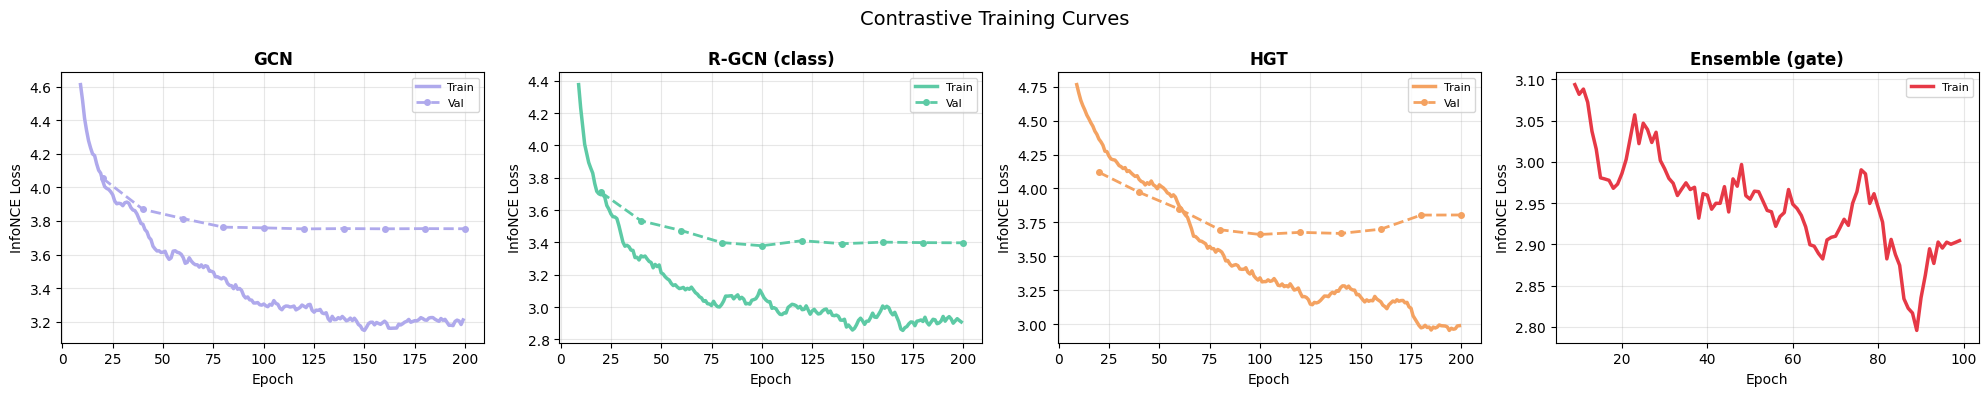

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
configs = [
    (gcn_tl,  gcn_vl,  "GCN",             "#AFA9EC"),
    (rgcn_tl, rgcn_vl, "R-GCN (class)",   "#5DCAA5"),
    (hgt_tl,  hgt_vl,  "HGT",             "#F4A261"),
    (ensemble_tl, [],  "Ensemble (gate)",  "#E63946"),
]
for ax, (tl, vl, name, color) in zip(axes, configs):
    w = 10
    smoothed = np.convolve(tl, np.ones(w)/w, mode="valid")
    ax.plot(range(w-1, len(tl)), smoothed, color=color, lw=2.5, label="Train")
    if vl:
        ve, vv = zip(*vl)
        ax.plot(ve, vv, color=color, lw=2, ls="--", marker="o", ms=4, label="Val")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("InfoNCE Loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Contrastive Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/figures/training_curves_all.png", dpi=150, bbox_inches="tight")
plt.show()

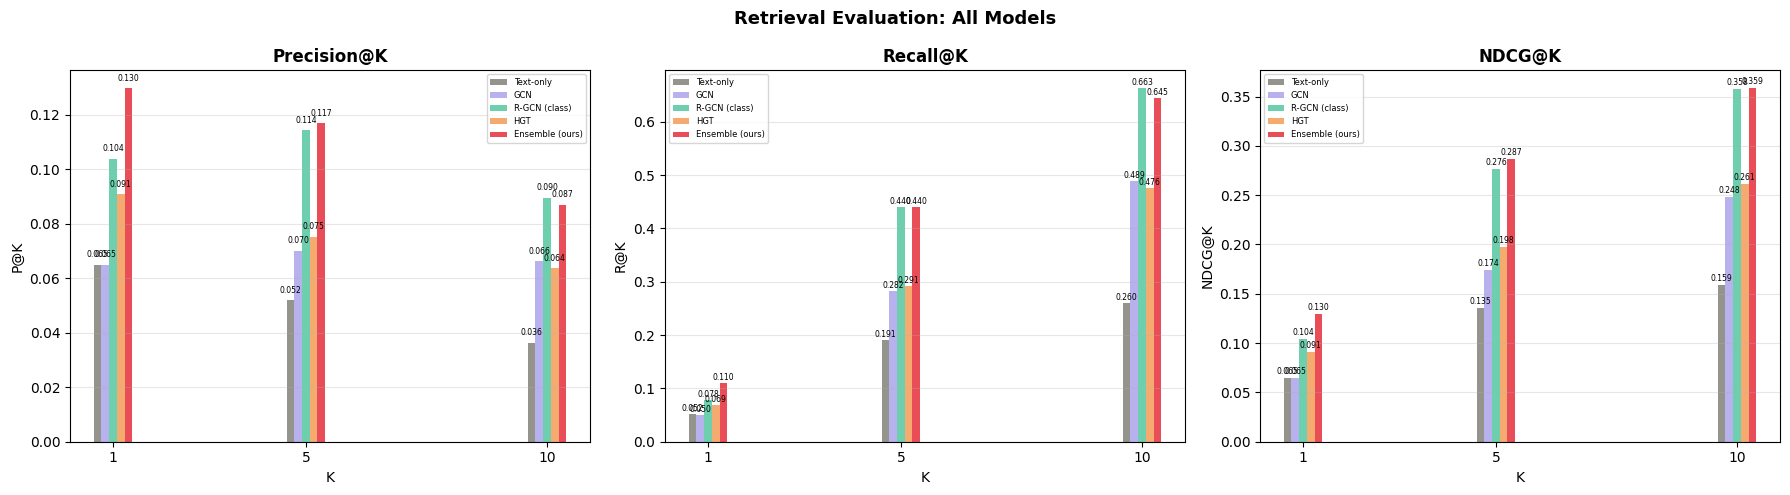

✅ All figures saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_keys = ["P@K", "R@K", "NDCG@K"]
titles      = ["Precision@K", "Recall@K", "NDCG@K"]
x           = np.array(K_VALUES)
width       = 0.16

colors = ["#888780", "#AFA9EC", "#5DCAA5", "#F4A261", "#E63946"]
labels = ["Text-only", "GCN", "R-GCN (class)", "HGT", "Ensemble (ours)"]
all_res_list = [raw_results, gcn_results, rgcn_results, hgt_results, ens_results]

for ax, metric, title in zip(axes, metric_keys, titles):
    for i, (res, label, color) in enumerate(zip(all_res_list, labels, colors)):
        vals   = [res[k][metric] for k in K_VALUES]
        offset = (i - 2) * width
        bars   = ax.bar(x + offset, vals, width, label=label, color=color, alpha=0.9)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=5.5)
    ax.set_xlabel("K"); ax.set_ylabel(metric)
    ax.set_title(title, fontweight="bold"); ax.set_xticks(x)
    ax.legend(fontsize=6); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Retrieval Evaluation: All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/retrieval_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ All figures saved")